### Importations

In [48]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt 
import numpy as np
import torch.nn as nn




### Constantes

In [49]:
IMG_SIZE = 64 #taille de l'Image
N_STEPS = 1500


### Dataset

In [50]:
def load_flattened(path, bg=(255, 255, 255)):
    img = Image.open(path).convert("RGBA")
    background = Image.new("RGBA", img.size, bg + (255,))
    return Image.alpha_composite(background, img).convert("RGB")


class SpriteDataset(Dataset):
    def __init__(self, root_dir, img_size = IMG_SIZE ):
        self.root_dir = root_dir
        self.files = [f for f in os.listdir(root_dir)
                      if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),                  # -> [0, 1]
            transforms.Normalize([0.5]*3, [0.5]*3), # -> [-1, 1]
        ])
        
    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = load_flattened(os.path.join(self.root_dir, self.files[idx]))
        return self.transform(img)

#dataset = SpriteDataset(root_dir="C:/Users/ryan0/Documents/ENSTA/1A/Pixel_art_generator/src/data/archive (1)/images/images/")

dataset = SpriteDataset(root_dir = "C:/Users/ryan0/Documents/ENSTA/1A/Pixel_art_generator/src/data/data/2")
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)
print(f"{len(dataset)} images chargées.")





912 images chargées.


### Visualisation

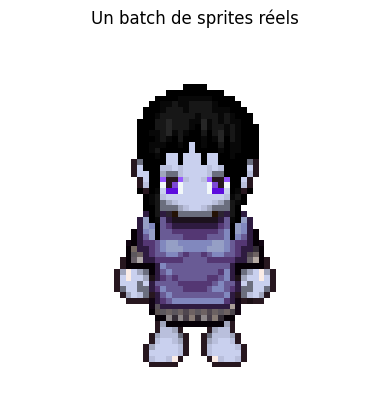

In [51]:
def show_batch(batch, n=16, title=None):
    batch = (batch[:n] + 1) / 2  # dénormalise [-1,1] -> [0,1] pour l'affichage
    cols = 4
    rows = n // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols, rows))
    for i, ax in enumerate(axes.flat):
        ax.imshow(batch[i].permute(1, 2, 0).numpy())
        ax.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

def show_single(img, title=None):
    img = (img[0] + 1) / 2       # retire la dimension batch, dénormalise
    img = img.clip(0, 1)
    plt.imshow(img.permute(1, 2, 0).numpy())
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

def show_comparison(reference, generated, titles=("Référence", "Généré")):
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    for ax, img, title in zip(axes, [reference, generated], titles):
        img = (img[0] + 1) / 2
        img = img.clip(0, 1)
        ax.imshow(img.permute(1, 2, 0).cpu().numpy())
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

batch = next(iter(dataloader))
show_single(batch, title="Un batch de sprites réels")

### Q-sample

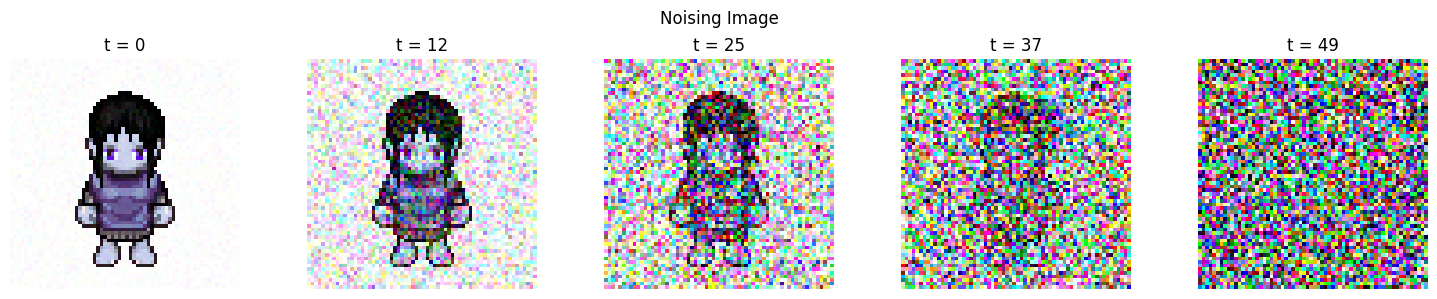

In [52]:

s = 0.008
T = 50

def g(t):
    t_tensor = torch.as_tensor(t)
    return torch.cos((t_tensor/T + s)/(1 + s) * torch.pi / 2) ** 2

def schedule(t):
    alpha_bar = g(t+1)/g(0)
    alpha_bar1 = g(t)/g(0)
    return 1-alpha_bar/alpha_bar1

t = torch.arange(0, T)
betas       = schedule(t)            # shape (T,)
betas = torch.clamp(betas, max=0.999)   # empêche alpha_t de tomber exactement à 0
alphas      = 1 - betas              # shape (T,)
alpha_bars  = torch.cumprod(alphas, dim=0)   # shape (T,)
alpha_bars_prev = torch.cat([torch.ones(1), alpha_bars[:-1]])


def q_sample(x0, t, alpha_bars, noise=None):
    """
    x0     : (B, C, H, W)
    t      : (B,) — indices entiers dans [0, T-1]
    noise  : (B, C, H, W) ou None (généré aléatoirement si None)
    retourne x_t, de même forme que x0
    """
    # 1. si noise est None, en générer un ~ N(0,I) de la forme de x0
    if noise is None:
    
        noise = torch.randn_like(x0)
    # 2. récupérer alpha_bars[t], le reshaper pour le broadcast
    alpha_bars_t = alpha_bars[t]
    alpha_bars_broadcast = alpha_bars_t.view(-1, 1, 1, 1)
   
    # 3. appliquer la formule fermée de la section 2
    x_t = torch.sqrt(alpha_bars_broadcast)*x0 + torch.sqrt( 1- alpha_bars_broadcast)* noise
    # 4. retourner x_t

    return x_t



def show_noise(x0, title = None):
    timesteps = [0, int(T/4), int(T/2), int(3*T/4), int(T-1)]
    plt.figure(figsize=(15, 3))
    for i, t in enumerate(timesteps):
        # t doit être passé sous forme de tenseur d'entiers de taille (1,)
        t_tensor = torch.tensor([t])
        xt = q_sample(x0, t_tensor, alpha_bars)
        # Dénormaliser de [-1, 1] vers [0, 1] pour un affichage correct
        img = (xt[0] + 1) / 2

        img = img.clip(0, 1) 
        
        # Dessiner le sous-graphe
        plt.subplot(1, len(timesteps), i + 1)

        plt.imshow(img.permute(1, 2, 0).numpy())
        
        plt.title(f"t = {t}")
        plt.axis("off")
    if title:
        plt.suptitle(title) # Masquer les axes de coordonnées
    plt.tight_layout()
    plt.show()


show_noise(batch[0:1], title = "Noising Image")

### U-net

#### Topologie

```text
x_t (B,3,32,32)
   │
 Conv in
   │
 ResBlock ──────────────────────────────┐  skip 0 (64ch @32×32)
   │                                     │
 Downsample                              │
   │                                     │
 ResBlock ──────────────┐ skip 1         │
   │                     │ (128ch @16×16)│
 Downsample              │               │
   │                     │               │
 ResBlock (bottleneck, 256ch @ 8×8)       │
   │                     │               │
 Self-Attention          │               │
   │                     │               │
 ResBlock                │               │
   │                     │               │
 Upsample                │               │
   │                     │               │
 concat ◄────────────────┘               │
   │                                     │
 ResBlock (128ch @16×16)                 │
   │                                     │
 Upsample                                │
   │                                     │
 concat ◄─────────────────────────────────┘
   │
 ResBlock (64ch @32×32)
   │
 Conv out
   │
ε_θ(x_t, t)  (B,3,32,32)

```


In [53]:

def sinusoidal_embedding(t, dim):
    """
    t   : (B,) entiers (timesteps)
    dim : dimension de sortie, paire
    retourne (B, dim)
    """
    device = t.device
    dimensions = torch.arange(dim, device=device)
    angle_rates = 1.0 / torch.pow(10000.0, (2 * (dimensions // 2)) / dim)
    angle_rads = t[:, None] * angle_rates[None, :]
    pos_encoding = torch.zeros(t.shape[0], dim, device=device)
    pos_encoding[:, 0::2] = torch.sin(angle_rads[:, 0::2])
    pos_encoding[:, 1::2] = torch.cos(angle_rads[:, 1::2])
    return pos_encoding


class TimeMLP(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.SiLU(),
            nn.Linear(dim, dim),
        )

    def forward(self, t_emb):
        return self.net(t_emb)


class ResBlock(nn.Module):
    """
    in_ch -> out_ch, injecte un embedding temporel de dimension emb_dim
    Entrée  : x (B, in_ch, H, W), t_emb (B, emb_dim)
    Sortie  : (B, out_ch, H, W)
    """
    def __init__(self, in_ch, out_ch, emb_dim):
        super().__init__()
        # chemin principal

        self.norm1 = nn.GroupNorm(num_groups=8, num_channels=in_ch)   # 1er "GN"
        self.act1  = nn.SiLU()                                        # 1er "SiLU"
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)  # 1ère "Conv 3×3"

        self.time_proj = nn.Linear(emb_dim, out_ch)   # projette l'embedding pour le cercle "+t"

        self.norm2 = nn.GroupNorm(num_groups=8, num_channels=out_ch)  # 2e "GN"
        self.act2  = nn.SiLU()                                         # 2e "SiLU"
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)  # 2e "Conv 3×3"

        # chemin du bas
        if in_ch != out_ch:
            self.skip = nn.Conv2d(in_ch, out_ch, kernel_size=1)   # la boîte "Conv 1×1 si in=!out"
        else:
            self.skip = nn.Identity()   # rien à faire, x passe tel quel

    def forward(self, x, t_emb):
        h = self.conv1(self.act1(self.norm1(x)))
        h = h + self.time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = self.conv2(self.act2(self.norm2(h)))
        return h + self.skip(x)


class Downsample(nn.Module):
    """ Conv3×3 stride 2 (ou AvgPool2d + Conv1×1) : (B,C,H,W) -> (B,C,H/2,W/2) """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=2, padding=1)

    def forward(self, x):
        return self.conv1(x)


class Upsample(nn.Module):
    """ Interpolation nearest ×2 puis Conv3×3 : (B,C,H,W) -> (B,C,2H,2W) """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)

    def forward(self, x):
        x = torch.nn.functional.interpolate(x, scale_factor=2, mode='nearest')
        return self.conv1(x)


class SelfAttention(nn.Module):
    """
    x : (B, C, H, W)
    1. reshape -> (B, H*W, C)             # chaque position spatiale = un token
    2. attention standard : softmax(QK^T / sqrt(C)) @ V
    3. reshape -> (B, C, H, W)
    4. + connexion résiduelle avec l'entrée d'origine
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.q = nn.Linear(in_ch, out_ch)
        self.k = nn.Linear(in_ch, out_ch)
        self.v = nn.Linear(in_ch, out_ch)

        if in_ch != out_ch:
            self.skip = nn.Conv2d(in_ch, out_ch, kernel_size=1)   # la boîte "Conv 1×1 si in=!out"
        else:
            self.skip = nn.Identity()

    def forward(self, x):
        B, C, H, W = x.shape
        x_flat = x.view(B, C, H * W).permute(0, 2, 1)
        
        q = self.q(x_flat)
        k = self.k(x_flat)
        v = self.v(x_flat)
        
        scores = torch.matmul(q, k.transpose(-2, -1)) / (q.shape[-1] ** 0.5)
        attn = torch.softmax(scores, dim=-1)
        
        out = torch.matmul(attn, v)
        out = out.permute(0, 2, 1).contiguous().view(B, -1, H, W)
        return out + self.skip(x)


class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=3, time_dim=256):
        super().__init__()
        
        self.time_mlp = nn.Sequential(
            TimeMLP(time_dim)
        )
        
        self.init_conv = nn.Conv2d(in_ch, 64, kernel_size=3, padding=1)
        
        # Encoder Level 0
        self.enc0 = ResBlock(in_ch=64, out_ch=64, emb_dim=time_dim)
        self.down0 = Downsample(in_ch=64, out_ch=64)
        
        # Encoder Level 1
        self.enc1 = ResBlock(in_ch=64, out_ch=128, emb_dim=time_dim)
        self.down1 = Downsample(in_ch=128, out_ch=128)
        
        # Bottleneck
        self.bottleneck1 = ResBlock(in_ch=128, out_ch=256, emb_dim=time_dim)
        self.attn = SelfAttention(in_ch=256, out_ch=256)
        self.bottleneck2 = ResBlock(in_ch=256, out_ch=256, emb_dim=time_dim)
        
        # Decoder Level 1
        self.up1 = Upsample(in_ch=256, out_ch=256)
        self.dec1 = ResBlock(in_ch=384, out_ch=128, emb_dim=time_dim)
        
        # Decoder Level 0
        self.up0 = Upsample(in_ch=128, out_ch=128)
        self.dec0 = ResBlock(in_ch=192, out_ch=64, emb_dim=time_dim)
        
        # Exit Conv
        self.out_norm = nn.GroupNorm(num_groups=8, num_channels=64)
        self.out_act = nn.SiLU()
        self.out_conv = nn.Conv2d(64, out_ch, kernel_size=3, padding=1)
        
        self.time_dim = time_dim

    def forward(self, x, t):
        t_emb = sinusoidal_embedding(t, self.time_dim)
        t_emb = self.time_mlp(t_emb)
        
        h = self.init_conv(x)  # (B, 64, 32, 32)
        
        skip0 = self.enc0(h, t_emb)  # (B, 64, 32, 32)
        h = self.down0(skip0)  # (B, 64, 16, 16)
        
        skip1 = self.enc1(h, t_emb)  # (B, 128, 16, 16)
        h = self.down1(skip1)  # (B, 128, 8, 8)
        
        h = self.bottleneck1(h, t_emb)  # (B, 256, 8, 8)
        h = self.attn(h)  # (B, 256, 8, 8)
        h = self.bottleneck2(h, t_emb)  # (B, 256, 8, 8)
        
        h = self.up1(h)  # (B, 256, 16, 16)
        h = torch.cat([h, skip1], dim=1)  # (B, 384, 16, 16)
        h = self.dec1(h, t_emb)  # (B, 128, 16, 16)
        
        h = self.up0(h)  # (B, 128, 32, 32)
        h = torch.cat([h, skip0], dim=1)  # (B, 192, 32, 32)
        h = self.dec0(h, t_emb)  # (B, 64, 32, 32)
        
        h = self.out_norm(h)
        h = self.out_act(h)
        h = self.out_conv(h)  # (B, 3, 32, 32)
        return h


In [54]:
model = UNet()
x_dummy = torch.randn(2, 3, 32, 32)
t_dummy = torch.randint(0, 300, (2,))
out = model(x_dummy, t_dummy)
print(out.shape)  # doit afficher torch.Size([2, 3, 32, 32])

torch.Size([2, 3, 32, 32])


### Loss

In [55]:
def train_step(model, optimizer, x0, alphas_cumprod, T, device):
    model.train()

    x0 = x0.to(device)
    alphas_cumprod = alphas_cumprod.to(device)
    B = x0.shape[0]
    t = torch.randint(0, T, (B,), device=device)          # (B,), dtype long
    noise = torch.randn_like(x0)                            # généré UNE fois, ici
    x_t = q_sample(x0, t, alphas_cumprod, noise=noise)       # on le repasse explicitement
    pred_noise = model(x_t, t)
    loss = torch.nn.functional.mse_loss(pred_noise, noise)  # comparaison au MÊME bruit
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

    

### Optimiseur


In [56]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

### Processus inverse

In [57]:
alpha_bars_prev = torch.cat([torch.ones(1, device='cpu'), alpha_bars[:-1]])  # ᾱ_{-1} := 1

@torch.no_grad()
def sample(model, shape, alphas, alpha_bars, alpha_bars_prev, betas, T, device):
    x_t = torch.randn(shape, device=device)
    for t_int in reversed(range(T)):
        t = torch.full((shape[0],), t_int, device=device, dtype=torch.long)
        beta_t = betas[t].view(-1, 1, 1, 1)
        alpha_t = alphas[t].view(-1, 1, 1, 1)
        alpha_bar_t = alpha_bars[t].view(-1, 1, 1, 1)
        alpha_bar_prev_t = alpha_bars_prev[t].view(-1, 1, 1, 1)

        pred_noise = model(x_t, t)

        x0_hat = (x_t - (1 - alpha_bar_t).sqrt() * pred_noise) / alpha_bar_t.sqrt()
        x0_hat = torch.clamp(x0_hat, -1.0, 1.0)   # le clip principié, sur x0 estimé

        mu = (alpha_bar_prev_t.sqrt() * beta_t / (1 - alpha_bar_t)) * x0_hat \
           + (alpha_t.sqrt() * (1 - alpha_bar_prev_t) / (1 - alpha_bar_t)) * x_t

        z = torch.randn_like(x_t) if t_int > 0 else torch.zeros_like(x_t)
        x_t = mu + beta_t.sqrt() * z
    return x_t

### Test de sur-apprentissage

step 0: loss = 1.1255
step 200: loss = 0.0628
step 400: loss = 0.0652
step 600: loss = 0.0684
step 800: loss = 0.0167
step 1000: loss = 0.0138
step 1200: loss = 0.0220
step 1400: loss = 0.0100
-0.3890140950679779 1.0


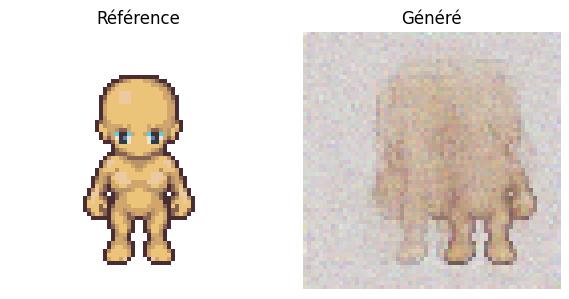

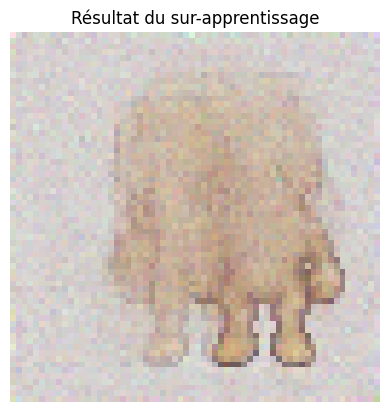

In [58]:
x0_single = dataset[0].unsqueeze(0).to(device = 'cpu')  # (1, C, H, W) — une seule image, fixée
x0_batch = x0_single.repeat(8, 1, 1, 1)   # même image, 8 copies



for step in range(N_STEPS):
    loss = train_step(model, optimizer, x0_batch, alpha_bars, T, device = 'cpu')
    if step % 200 == 0:
        print(f"step {step}: loss = {loss:.4f}")
model.eval()
generated = sample(model, shape=(1, 3, IMG_SIZE, IMG_SIZE), alphas = alphas, alpha_bars = alpha_bars
, betas= betas, T=T, device = 'cpu', alpha_bars_prev = alpha_bars_prev )
print(generated.min().item(), generated.max().item())




show_comparison(x0_batch, generated)

show_single(generated, title="Résultat du sur-apprentissage")

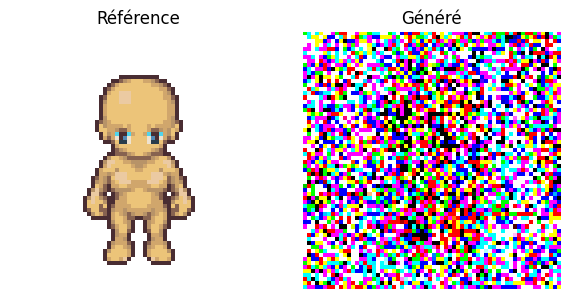

MSE avant (bruité)   : 1.8380
MSE après (débruité) : 1.7412


In [59]:
x0_single = dataset[0].unsqueeze(0).to(device = 'cpu')  # (1, C, H, W) — une seule image, fixée
x0_batch = x0_single.repeat(8, 1, 1, 1)   # même image, 8 copies

t_test = torch.full((1,), T-1, dtype=torch.long)
noise_test = torch.randn_like(x0_batch)
x_t_test = q_sample(x0_batch, t_test, alpha_bars, noise=noise_test)

model.eval()
with torch.no_grad():
    pred_noise_test = model(x_t_test, t_test)

alpha_bar_t = alpha_bars[t_test].view(-1, 1, 1, 1)
x0_hat_test = (x_t_test - (1 - alpha_bar_t).sqrt() * pred_noise_test) / alpha_bar_t.sqrt()
x0_hat_test = x0_hat_test.clamp(-1, 1)

show_comparison(x0_batch, x0_hat_test)
baseline_mse = torch.nn.functional.mse_loss(x_t_test, x0_batch).item()
reconstruction_mse = torch.nn.functional.mse_loss(x0_hat_test, x0_batch).item()
print(f"MSE avant (bruité)   : {baseline_mse:.4f}")
print(f"MSE après (débruité) : {reconstruction_mse:.4f}")

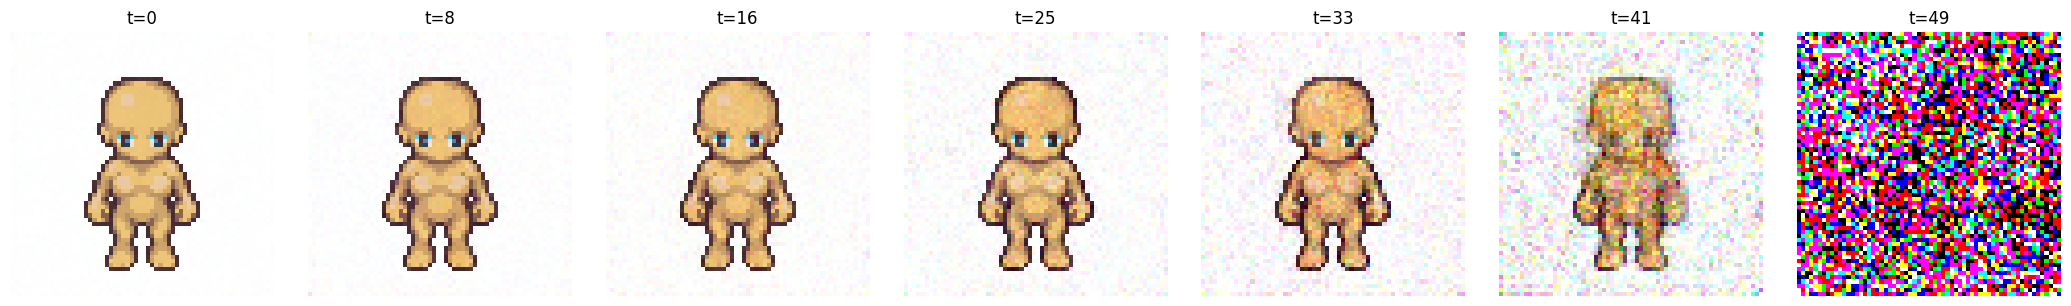

In [63]:
def diagnostic_grid(model, x0, alpha_bars, T, ts_to_test=None):
    if ts_to_test is None:
        ts_to_test = [0, T//6, T//3, T//2, 2*T//3, 5*T//6, T-1]
    model.eval()
    fig, axes = plt.subplots(1, len(ts_to_test), figsize=(3*len(ts_to_test), 3))
    with torch.no_grad():
        for ax, t_int in zip(axes, ts_to_test):
            t = torch.full((1,), t_int, dtype=torch.long)
            noise = torch.randn_like(x0)
            x_t = q_sample(x0, t, alpha_bars, noise=noise)
            pred_noise = model(x_t, t)
            alpha_bar_t = alpha_bars[t].view(-1, 1, 1, 1)
            x0_hat = ((x_t - (1 - alpha_bar_t).sqrt() * pred_noise) / alpha_bar_t.sqrt()).clamp(-1, 1)
            img = ((x0_hat[0] + 1) / 2).clip(0, 1).permute(1, 2, 0).numpy()
            ax.imshow(img)
            ax.set_title(f"t={t_int}")
            ax.axis("off")
    plt.tight_layout()
    plt.show()
diagnostic_grid(model, x0_batch, alpha_bars, T)

### Entrainement sur l'ensemble du dataset

In [64]:
import time

n_bench = 10
t0 = time.time()
for i, batch in enumerate(dataloader):
    if i >= n_bench:
        break
    train_step(model, optimizer, batch, alpha_bars, T, device= 'cpu')
elapsed = time.time() - t0
print(f"{elapsed/n_bench:.2f} s/step")

steps_per_epoch = len(dataset) // dataloader.batch_size
print(f"{steps_per_epoch} steps/epoch -> ~{steps_per_epoch * elapsed/n_bench / 60:.1f} min/epoch")

2.05 s/step
57 steps/epoch -> ~2.0 min/epoch


In [66]:
t0 = time.time()
generated = sample(model, shape=(1, 3, IMG_SIZE, IMG_SIZE),
                    alphas=alphas, alpha_bars=alpha_bars,
                    alpha_bars_prev=alpha_bars_prev, betas=betas, T=T, device='cpu')
print(f"{time.time() - t0:.2f} s pour un sample() complet")

2.17 s pour un sample() complet


In [ ]:
N_EPOCHS = 40     
K = 1                  
SAVE_EVERY = 5 

In [ ]:
import os
import json

import torch
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Configuration — tout au même endroit, plutôt que des chaînes/nombres éparpillés
# ---------------------------------------------------------------------------
DEVICE = "cpu"
CKPT_DIR = "checkpoints"
SAMPLES_DIR = "samples"
LOG_PATH = "training_log.json"

K = 1                    # fréquence de log_samples (en epochs)
MILESTONE_EVERY = 25     # fréquence des checkpoints permanents (en epochs)
N_EPOCHS_THIS_RUN = 30
SAMPLE_SEED = 42         # graine fixe : rend les échantillons comparables d'une epoch à l'autre

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(SAMPLES_DIR, exist_ok=True)


# ---------------------------------------------------------------------------
# Checkpointing
# ---------------------------------------------------------------------------
def save_checkpoint(model, optimizer, epoch, path):
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
    }, path)


def load_checkpoint(model, optimizer, path, device):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    return ckpt["epoch"]


def find_latest_checkpoint(ckpt_dir=CKPT_DIR):
    path = os.path.join(ckpt_dir, "latest.pt")
    return path if os.path.exists(path) else None


# ---------------------------------------------------------------------------
# Journal d'entraînement — persistant sur disque, survit à un redémarrage du noyau
# ---------------------------------------------------------------------------
def load_log(path=LOG_PATH):
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return {"loss": [], "recon_mse": []}


def save_log(log, path=LOG_PATH):
    with open(path, "w") as f:
        json.dump(log, f)


# ---------------------------------------------------------------------------
# Surveillance visuelle — graine fixée pour des échantillons comparables
# ---------------------------------------------------------------------------
@torch.no_grad()
def log_samples(model, epoch, alphas, alpha_bars, alpha_bars_prev, betas, T,
                 device, out_dir, seed=SAMPLE_SEED):
    model.eval()
    torch.manual_seed(seed)   # même x_T et mêmes z injectés à chaque appel
    generated = sample(model, shape=(1, 3, IMG_SIZE, IMG_SIZE),
                        alphas=alphas, alpha_bars=alpha_bars,
                        alpha_bars_prev=alpha_bars_prev, betas=betas, T=T, device=device)
    img = ((generated[0] + 1) / 2).clip(0, 1).permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"epoch {epoch}")
    plt.savefig(f"{out_dir}/sample_epoch{epoch:04d}.png")
    plt.close()
    model.train()


# ---------------------------------------------------------------------------
# Suivi quantitatif — déterministe (contrairement à log_samples), sur une
# image et un t fixés une fois pour toutes
# ---------------------------------------------------------------------------
@torch.no_grad()
def eval_reconstruction(model, x0, t, noise, alpha_bars):
    model.eval()
    x_t = q_sample(x0, t, alpha_bars, noise=noise)
    pred_noise = model(x_t, t)
    alpha_bar_t = alpha_bars[t].view(-1, 1, 1, 1)
    x0_hat = ((x_t - (1 - alpha_bar_t).sqrt() * pred_noise) / alpha_bar_t.sqrt()).clamp(-1, 1)
    mse = torch.nn.functional.mse_loss(x0_hat, x0).item()
    model.train()
    return mse


# ---------------------------------------------------------------------------
# Reprise depuis le dernier checkpoint, si présent
# ---------------------------------------------------------------------------
start_epoch = 0
latest = find_latest_checkpoint()
if latest:
    start_epoch = load_checkpoint(model, optimizer, latest, device=DEVICE) + 1
    print(f"reprise à l'epoch {start_epoch}")

log = load_log()

# référence fixe pour eval_reconstruction — calculée UNE fois, jamais régénérée
x0_ref = dataset[0].unsqueeze(0).to(DEVICE)
t_ref = torch.full((1,), T // 2, dtype=torch.long, device=DEVICE)
noise_ref = torch.randn_like(x0_ref)


# ---------------------------------------------------------------------------
# Boucle d'entraînement
# ---------------------------------------------------------------------------
for epoch in range(start_epoch, start_epoch + N_EPOCHS_THIS_RUN):
    epoch_losses = []
    for batch in dataloader:
        loss = train_step(model, optimizer, batch, alpha_bars, T, DEVICE)
        epoch_losses.append(loss)
    avg_loss = sum(epoch_losses) / len(epoch_losses)

    recon_mse = eval_reconstruction(model, x0_ref, t_ref, noise_ref, alpha_bars)

    log["loss"].append(avg_loss)
    log["recon_mse"].append(recon_mse)
    save_log(log)

    print(f"epoch {epoch}: loss moyenne = {avg_loss:.4f}  |  MSE reconstruction = {recon_mse:.4f}")

    if epoch % K == 0:
        log_samples(model, epoch, alphas, alpha_bars, alpha_bars_prev, betas, T, DEVICE, SAMPLES_DIR)

    save_checkpoint(model, optimizer, epoch, os.path.join(CKPT_DIR, "latest.pt"))   # toujours écrasé

    if epoch % MILESTONE_EVERY == 0:
        save_checkpoint(model, optimizer, epoch, os.path.join(CKPT_DIR, f"ckpt_epoch{epoch:04d}.pt"))

epoch 0: loss moyenne = 0.0717
epoch 1: loss moyenne = 0.0641
epoch 2: loss moyenne = 0.0599
epoch 3: loss moyenne = 0.0600
epoch 4: loss moyenne = 0.0562
epoch 5: loss moyenne = 0.0558
epoch 6: loss moyenne = 0.0546
epoch 7: loss moyenne = 0.0529
epoch 8: loss moyenne = 0.0519
epoch 9: loss moyenne = 0.0495
epoch 10: loss moyenne = 0.0480
epoch 11: loss moyenne = 0.0470
epoch 12: loss moyenne = 0.0491
epoch 13: loss moyenne = 0.0463
epoch 14: loss moyenne = 0.0450
